# Filter airports = (leave only EU airoports)
We use [Open airoports](https://ourairports.com/data/) dataset



In [36]:
import pandas as pd
df = pd.read_csv("./data/raw/airports.csv")
df.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [37]:
from graph_creation.config import get_our_countries
country_codes = get_our_countries()
country_codes_in_df = list(df['iso_country'].unique())

set(country_codes) - set(country_codes_in_df) # country codes are matched

set()

In [38]:
df['type'].unique() # we will use only 'small_airport', 'medium_airport', 'large_airport'

<StringArray>
[      'heliport',  'small_airport',  'seaplane_base',         'closed',
 'medium_airport',    'balloonport',  'large_airport']
Length: 7, dtype: str

In [39]:
df = df[['icao_code', 'name', 'type', 'iso_country', 'iso_region', 'municipality', 'latitude_deg', 'longitude_deg']]

only_eu_mask = df['iso_country'].apply(lambda x: x in country_codes)
only_aeroports_mask = df['type'].apply(lambda x: x in ['small_airport', 'medium_airport', 'large_airport'])
icao_code_exists_mask = ~df['icao_code'].isna()

mask = only_eu_mask & only_aeroports_mask & icao_code_exists_mask

eu_aeroports_df = df[mask]
eu_aeroports_df = eu_aeroports_df[~eu_aeroports_df['municipality'].isna()]
eu_aeroports_df.head()

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
12527,EBLB,Elsenborn Air Base,small_airport,BE,BE-WLG,Bütgenbach,50.484818,6.183014
12580,LBDM,Dve Mogili Airfield,small_airport,BG,BG-18,Dve Mogili,43.606541,25.890690
12592,LBBB,Belchinski Bani Airstrip,small_airport,BG,BG-23,Belchinski Bani,42.374713,23.392548
12594,LBBL,Blagoevo Airfield,small_airport,BG,BG-17,Blagoevo,43.455488,26.431655
12597,LBDR,Draganovtsi Airfield,small_airport,BG,BG-07,Draganovtsi,42.943042,25.169528


In [40]:
# We do not have airports in Liechtenstein
set(country_codes) - set(eu_aeroports_df['iso_country'].unique())

{'LI'}

In [41]:
len(eu_aeroports_df['iso_country'].unique()) # aeroports for 31 countries remains

32

In [42]:
eu_aeroports_df.isna().sum().sum()

np.int64(0)

In [43]:
eu_aeroports_df.shape

(1505, 8)

In [44]:
# cheating a bit :) 
# we do not use in the graph. This data should be learned from the graph itself
eu_aeroports_df['type'].value_counts()

type
small_airport     733
medium_airport    525
large_airport     247
Name: count, dtype: int64

We see that we have too many small airoports. They usually are military bases. Let's drop them

In [45]:
military_words = ["air base", "airfield"]
def check(name: str):
    name = name.lower()
    for word in military_words:
        if word in name:
            return True
    return False


not_military_mask = ~eu_aeroports_df["name"].apply(check)
eu_aeroports_df = eu_aeroports_df[not_military_mask]

In [46]:
# much better
eu_aeroports_df['type'].value_counts()

type
medium_airport    422
large_airport     247
small_airport     221
Name: count, dtype: int64

## Paris, Istanbul, London, Bucharest problem
Paris, Istanbul, London, Bucharest have many airoports. In our df they are named differently (Le Touquet-Paris-Plage, Paris, Paris (Roissy-en-France, Val-d'Oise) etc). Let's rename to one singular name - Paris, Istanbul, London, Bucharest respectively - to get right aggregations by these cities

In [47]:
paris_mask = eu_aeroports_df['municipality'].apply(lambda x: "Paris" in x)
eu_aeroports_df[paris_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
43032,LFAT,Le Touquet-Côte d'Opale Airport,medium_airport,FR,FR-HDF,Le Touquet-Paris-Plage,50.518284,1.621656
43342,LFPB,Paris-Le Bourget International Airport,large_airport,FR,FR-IDF,Paris,48.962276,2.436539
43347,LFPG,Charles de Gaulle International Airport,large_airport,FR,FR-IDF,"Paris (Roissy-en-France, Val-d'Oise)",49.008960,2.554117
43354,LFPO,Paris-Orly Airport,large_airport,FR,FR-IDF,"Paris (Orly, Val-de-Marne)",48.723330,2.379440


In [48]:
eu_aeroports_df.loc[eu_aeroports_df[paris_mask].index, "municipality"] = "Paris"
eu_aeroports_df[paris_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
43032,LFAT,Le Touquet-Côte d'Opale Airport,medium_airport,FR,FR-HDF,Paris,50.518284,1.621656
43342,LFPB,Paris-Le Bourget International Airport,large_airport,FR,FR-IDF,Paris,48.962276,2.436539
43347,LFPG,Charles de Gaulle International Airport,large_airport,FR,FR-IDF,Paris,49.008960,2.554117
43354,LFPO,Paris-Orly Airport,large_airport,FR,FR-IDF,Paris,48.723330,2.379440


In [49]:
istanbul_mask = eu_aeroports_df['municipality'].apply(lambda x: "Istanbul" in x)
eu_aeroports_df[istanbul_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44398,LTBA,İstanbul Atatürk Airport,large_airport,TR,TR-34,Istanbul(Bakırköy),40.971913,28.823714
44453,LTFJ,Istanbul Sabiha Gökçen International Airport,large_airport,TR,TR-34,"Pendik, Istanbul",40.898602,29.309200
44455,LTFM,İstanbul Airport,large_airport,TR,TR-34,Istanbul,41.274874,28.732136


In [50]:
eu_aeroports_df.loc[eu_aeroports_df[istanbul_mask].index, "municipality"] = "Istanbul"
eu_aeroports_df[istanbul_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44398,LTBA,İstanbul Atatürk Airport,large_airport,TR,TR-34,Istanbul,40.971913,28.823714
44453,LTFJ,Istanbul Sabiha Gökçen International Airport,large_airport,TR,TR-34,Istanbul,40.898602,29.309200
44455,LTFM,İstanbul Airport,large_airport,TR,TR-34,Istanbul,41.274874,28.732136


In [51]:
london_mask = eu_aeroports_df['municipality'].apply(lambda x: "London" in x)
eu_aeroports_df[london_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
23922,EGKB,London Biggin Hill Airport,medium_airport,GB,GB-ENG,London,51.330799,0.032500
23926,EGKK,London Gatwick Airport,large_airport,GB,GB-ENG,London,51.148744,-0.185739
23930,EGLC,London City Airport,medium_airport,GB,GB-ENG,London,51.505299,0.055278
23935,EGLL,London Heathrow Airport,large_airport,GB,GB-ENG,London,51.470748,-0.459909
23946,EGML,Damyns Hall Aerodrome,small_airport,GB,GB-ENG,"Upminster, Greater London",51.527561,0.244189
23998,EGSG,Stapleford Aerodrome,small_airport,GB,GB-ENG,"Romford, Greater London",51.652500,0.155833
24008,EGSS,London Stansted Airport,large_airport,GB,GB-ENG,"London, Essex",51.884998,0.235000
24042,EGWU,RAF Northolt,medium_airport,GB,GB-ENG,"Northolt, Greater London",51.553001,-0.418167


In [52]:
eu_aeroports_df.loc[eu_aeroports_df[london_mask].index, "municipality"] = "London"
eu_aeroports_df[london_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
23922,EGKB,London Biggin Hill Airport,medium_airport,GB,GB-ENG,London,51.330799,0.032500
23926,EGKK,London Gatwick Airport,large_airport,GB,GB-ENG,London,51.148744,-0.185739
23930,EGLC,London City Airport,medium_airport,GB,GB-ENG,London,51.505299,0.055278
23935,EGLL,London Heathrow Airport,large_airport,GB,GB-ENG,London,51.470748,-0.459909
23946,EGML,Damyns Hall Aerodrome,small_airport,GB,GB-ENG,London,51.527561,0.244189
23998,EGSG,Stapleford Aerodrome,small_airport,GB,GB-ENG,London,51.652500,0.155833
24008,EGSS,London Stansted Airport,large_airport,GB,GB-ENG,London,51.884998,0.235000
24042,EGWU,RAF Northolt,medium_airport,GB,GB-ENG,London,51.553001,-0.418167


In [53]:
bucharest_mask = eu_aeroports_df['municipality'].apply(lambda x: "Otopeni" in x or "Bucharest" in x)
eu_aeroports_df[bucharest_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44144,LRBS,Bucharest Băneasa Aurel Vlaicu International A...,large_airport,RO,RO-B,Bucharest,44.503133,26.102944
44160,LROP,Bucharest Henri Coandă International Airport,large_airport,RO,RO-IF,Otopeni,44.571792,26.103285


In [54]:
eu_aeroports_df.loc[eu_aeroports_df[bucharest_mask].index, "municipality"] = "Bucharest"
eu_aeroports_df[bucharest_mask]

,icao_code,name,type,iso_country,iso_region,municipality,latitude_deg,longitude_deg
44144,LRBS,Bucharest Băneasa Aurel Vlaicu International A...,large_airport,RO,RO-B,Bucharest,44.503133,26.102944
44160,LROP,Bucharest Henri Coandă International Airport,large_airport,RO,RO-IF,Bucharest,44.571792,26.103285


In [55]:
eu_aeroports_df.to_csv("./data/raw/eu_aeroports.csv", index=False)

## Aeroports to municipality aggregation
Several municipalities have more than one airport, lets aggregate them to municipality unit

In [56]:
# the same as eu_aeroports_df[['municipality']].value_counts().value_counts()
eu_aeroports_df.groupby('municipality')['icao_code'].count().value_counts()

icao_code
1    832
2     20
3      2
8      1
4      1
Name: count, dtype: int64

In [57]:
eu_aeroports_df[['municipality', 'iso_country']].value_counts().value_counts()

count
1    832
2     20
3      2
8      1
4      1
Name: count, dtype: int64

We do not have airoports with the same name located in different countries. Nevertheless we will use municipality name + country code as id. 

In [58]:
municipality_df = (
    eu_aeroports_df
    .groupby(["municipality", "iso_country"], as_index=False)
    .agg(
        icao_codes=("icao_code", list),
        iso_country=("iso_country", "first"),
        iso_region=("iso_region", "first"),
        latitude_deg=("latitude_deg", "mean"),
        longitude_deg=("longitude_deg", "mean"),
    )
)
municipality_df.head()

,municipality,icao_codes,iso_country,iso_region,latitude_deg,longitude_deg
0,Aachen,[EDKA],DE,DE-NW,50.823055,6.186389
1,Aalborg,[EKYT],DK,DK-81,57.094763,9.849930
2,Aarhus,[EKAH],DK,DK-82,56.303331,10.618286
3,Abbeyshrule,[EIAB],IE,IE-LD,53.591373,-7.642947
4,Aberdeen,[EGPD],GB,GB-SCT,57.201900,-2.197780


In [59]:
# drop brackets for airports
municipality_df['icao_codes'] = municipality_df['icao_codes'].apply(lambda x: ", ".join(x))
municipality_df.head()

,municipality,icao_codes,iso_country,iso_region,latitude_deg,longitude_deg
0,Aachen,EDKA,DE,DE-NW,50.823055,6.186389
1,Aalborg,EKYT,DK,DK-81,57.094763,9.849930
2,Aarhus,EKAH,DK,DK-82,56.303331,10.618286
3,Abbeyshrule,EIAB,IE,IE-LD,53.591373,-7.642947
4,Aberdeen,EGPD,GB,GB-SCT,57.201900,-2.197780


In [60]:
municipality_df.rename(columns={"icao_codes": "airports"}, inplace=True)

In [61]:
municipality_df.to_csv("./data/municipality.csv", index=False)

# Graph creation
We load data about flight frome OpenSKY provider. We collect data for one week: from 16 feb (mon) til 22 feb (sun). We can not load the whole week (400 error - too big timeframe), so we create one graph for 1 or 2 days, and then we merge them into one graph for the week.

In [62]:
from graph_creation.bootstrap import bootsrap_create_save_graph_use_case
u = bootsrap_create_save_graph_use_case()

u.run("2026-02-16", day_interval_number=1, graph_name="2026-02-16")

loaded 108842 flights from OpenSky
flights with empty arr/dep = 33876
flights with empty icao or callsign = 39
unknown or non-eu departures: 58679
unknown or non-eu arrivals: 2211
self loops (flights within the same municipality): 938
not enough distance: 365
Graph created with 378 nodes and 4875 edges, flights: 12734


In [63]:
u.run("2026-02-17", day_interval_number=2, graph_name="2026-02-17_18")

loaded 225192 flights from OpenSky
flights with empty arr/dep = 70663
flights with empty icao or callsign = 108
unknown or non-eu departures: 124988
unknown or non-eu arrivals: 4465
self loops (flights within the same municipality): 2391
not enough distance: 845
Graph created with 427 nodes and 5385 edges, flights: 21732


In [64]:
u.run("2026-02-19", day_interval_number=2, graph_name="2026-02-19_20")

loaded 234369 flights from OpenSky
flights with empty arr/dep = 73382
flights with empty icao or callsign = 142
unknown or non-eu departures: 128398
unknown or non-eu arrivals: 4371
self loops (flights within the same municipality): 1943
not enough distance: 605
Graph created with 415 nodes and 6366 edges, flights: 25528


In [65]:
u.run("2026-02-21", day_interval_number=2, graph_name="2026-02-21_22")

loaded 218753 flights from OpenSky
flights with empty arr/dep = 69198
flights with empty icao or callsign = 113
unknown or non-eu departures: 118669
unknown or non-eu arrivals: 4059
self loops (flights within the same municipality): 1510
not enough distance: 646
Graph created with 404 nodes and 6264 edges, flights: 24558


In [66]:
from graph_creation.adapters.input import GraphJsonLoader
g1 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-16.json")
g2 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-17_18.json")
g3 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-19_20.json")
g4 = GraphJsonLoader().load("./data/graphs_json_html/2026-02-21_22.json")

In [67]:
week_g = g1 + g2 + g3 + g4
week_g

Graph(nodes_number=509, edges_number=9968, unknown_or_non_eu_dep=430734, unknown_or_non_eu_arr=15106, countries=['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'TR'], begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [68]:
from graph_creation.adapters.output.graph import GraphPandasAdapter
graph_to_pandas = GraphPandasAdapter(week_g)

nodes_df = graph_to_pandas.nodes_to_df()
nodes_df.head()

,id,name,iso_country,iso_region,latitude,longitude,airports_count,out_flights_number,in_flights_number,nut3_code
0,"Alava, ES",Alava,ES,ES-PV,42.882801,-2.724470,1,12,24,None
1,"Örebro, SE",Örebro,SE,SE-T,59.223701,15.038000,1,17,20,None
2,"Thessaloniki, GR",Thessaloniki,GR,GR-B,40.519280,22.970009,1,301,346,None
3,"Kuopio / Siilinjärvi, FI",Kuopio / Siilinjärvi,FI,FI-15,63.007099,27.797800,1,36,36,None
4,"Kidlington, Oxfordshire, GB","Kidlington, Oxfordshire",GB,GB-ENG,51.836899,-1.320000,1,36,46,None


In [69]:
nodes_df.isna().sum() # nut3_code has not been set yet, it should be null

id                      0
name                    0
iso_country             0
iso_region              0
latitude                0
longitude               0
airports_count          0
out_flights_number      0
in_flights_number       0
nut3_code             509
dtype: int64

In [70]:
nodes_df['id'].value_counts().value_counts() # no node dupplicates, excellent (＊◕ᴗ◕＊)

count
1    509
Name: count, dtype: int64

In [71]:
nodes_df.to_csv("./data/graph_csv/nodes.csv", index=False)

In [72]:
edges_df = graph_to_pandas.edges_to_df()
edges_df.head()

,from_id,to_id,weight,distance
0,"Aalborg, DK","Billund, DK",2,156.52
1,"Aalborg, DK","Oslo (Gardermoen), NO",6,352.11
2,"Aalborg, DK","Copenhagen, DK",84,238.40
3,"Aalborg, DK","Amsterdam, NL",28,624.13
4,"Aalborg, DK","Málaga, ES",3,2507.05


In [73]:
edges_df.isna().sum().sum()

np.int64(0)

In [74]:
edges_df.to_csv("./data/graph_csv/edges.csv", index=False)

In [76]:
flights_df = graph_to_pandas.flights_to_df()
flights_df.head()

,icao,callsign,count
0,45d069,VKG4587,1
1,45884d,OYBBM,2
2,47875c,NOZ1259,1
3,4aca76,SAS99H,1
4,4aca74,SAS99H,1


In [77]:
flights_df.isna().sum().sum()

np.int64(0)

In [78]:
flights_df.to_csv("./data/graph_csv/flights.csv", index=False)

In [79]:
from graph_creation.adapters.output import GraphJsonExporter

exporter = GraphJsonExporter("data")
exporter.export(week_g, "flights_week_graph.json")

# Load nuts3 PPS data from eurostat
Gross domestic product (GDP) at current market prices by NUTS 3 region, [eurostat](https://ec.europa.eu/eurostat/databrowser/view/nama_10r_3gdp__custom_16402140/bookmark/table?lang=en&bookmarkId=3edea12e-d6ab-46cd-ab3e-d547d9bae3c1&c=1745826708191). We can load data with eurostat API. 

Our final table contains 3 columns:
- nut3_code
- pps, in millions of points
- pps per inhabitant, points

In [80]:
from graph_creation.adapters.input.pps_from_eurostat_loader import load_nuts3_gdp
pps_df = load_nuts3_gdp()
pps_df.head()

unit,nut3_code,pps,pps_per_inhabitant
0,AT,436203.37,47500.0
1,AT1,188494.63,46600.0
2,AT11,10384.18,34400.0
3,AT12,67871.36,39300.0
4,AT13,110239.09,54600.0


In [81]:
pps_df.to_csv("./data/nuts3_pps.csv", index=False)

# Get LAU to NUT3 df
## Parse EU NUT3 regions excel file
Correspondence tables, NUTS regions (EU-27), [eurostat](https://ec.europa.eu/eurostat/web/nuts/correspondence-tables)


In [82]:
import pandas as pd 

input_path = "./data/raw/eu_27_lau_nuts_2024.xlsx"
xls = pd.ExcelFile(input_path)

country_sheets = [e for e in xls.sheet_names if len(e) == 2]
print(len(country_sheets))

32


In [83]:
from graph_creation.config import get_our_countries
# Greece is clalled Elada 'EL' instead of "GR"
my_countries_sheets = get_our_countries() 
set(country_sheets) - set(my_countries_sheets) 

{'EL'}

In [84]:
my_countries_sheets.remove("GR")
my_countries_sheets.append("EL")

In [85]:
# TODO rename nut3 to nuts3 everywhere

def load_nut3_to_municipality_mapping(xls: pd.ExcelFile, country_sheets: list[str]) -> dict[str, dict[str, str]]:
    country_mapping = {}

    for sheet in country_sheets:
        if sheet == 'GB':
            country_mapping['GB'] = {}
            continue

        df = pd.read_excel(xls, sheet_name=sheet)

        columns_renaming = {"NUTS3": "nut3_code", "LAU NAME LATIN": "lau_name_latin"}
        if sheet == "TR":
            columns_renaming["NUTS 3 CODE"] = "nut3_code"

        df.rename(columns=columns_renaming, inplace=True)

        key = sheet if sheet != "EL" else "GR"
        country_mapping[key] = {}

        for row in df.itertuples():
            if isinstance(row.lau_name_latin, str) and isinstance(row.nut3_code, str):
                country_mapping[key][row.lau_name_latin.lower()] = row.nut3_code.split()[0]
    
    return country_mapping

country_mapping = load_nut3_to_municipality_mapping(xls, my_countries_sheets)

Despite having a mapping from LAU to NUTS3, we still have to mach our nodes (municipalities) to NUTS3 regions. This is quite a challenging task, because the data is inconsistent: we have additional information brackets, words ("municipality", "island" etc), translation to nation language, province code, second name etc. We have to look at each countries' dictionary separately and create a cleaning mapping :(

In [86]:
from graph_creation.adapters.input import GraphJsonLoader
from graph_creation.adapters.output.graph.pandas_adapter import GraphPandasAdapter
g = GraphJsonLoader().load("./data/flights_week_graph.json")
ga = GraphPandasAdapter(g)

g

Graph(nodes_number=509, edges_number=9968, unknown_or_non_eu_dep=430734, unknown_or_non_eu_arr=15106, countries=['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'TR'], begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [87]:
ga.nodes_to_df()['nut3_code'].isna().sum() # all null, as expected

np.int64(509)

In [88]:
cleaning_mapping = {}

def mapping_decorator(country_codes: list[str]):
    def decorator(func):
        for country_code in country_codes:
            cleaning_mapping[country_code] = func
        return func
    return decorator

@mapping_decorator(["GR"])
def cleaning(name: str):
    name = name.lower()
    for word in ["municipality", "island"]:
        name = name.replace(word, "")
    return name.strip()

@mapping_decorator(["DE", "HR", "CY", "PL"])
def cleaning(name: str):
    name = name.lower()
    if "(" in name:
        name = name[:name.index("(")]
    return name.strip()

@mapping_decorator(["FI", "IT"])
def cleaning(name: str):
    return name.split()[0].lower().strip()


@mapping_decorator(["ES", "SE", "FR", "NO"])
def cleaning(name: str):
    name = name.lower().strip(' island')
    if ',' in name:
        name = name.split(",")[0]
    if '/' in name:
        name = name.split("/")[0]
    if '(' in name:
        name = name.split("(")[0]
    return name.strip()

In [89]:
my_countries_codes = get_our_countries()
found_number, not_found_number = 0, 0

with open("./data/not_found_lst.txt", "w") as f:
    for node in g.nodes:
        found_flag = False
        country_code, municipality_name = node.iso_country, node.name

        if country_code in cleaning_mapping:
            municipality_name = cleaning_mapping[country_code](municipality_name)
        else:
            municipality_name = municipality_name.lower()

        for name_with_nut3 in country_mapping[country_code]:
            if municipality_name in name_with_nut3:
                node.nut3_code = country_mapping[country_code][name_with_nut3] 
                found_number += 1
                found_flag = True
                break
        
        if not found_flag:
            if country_code != "GB":
                not_found_number += 1
                print(f"{node.name}, {country_code}", file=f)

print(f"Found: {found_number}, Not found: {not_found_number}")

Found: 356, Not found: 90


We have matched 80% of our nodes to NUTS3 regions. The rest should be googled manually or answered by google ai mode

In [90]:
dct = {}
with open("./data/nuts3_from_google.txt") as f:
    # Florø, NO: NO0A2 (Vestland)
    for line in f:
        name = line.split(",")[0].strip()
        nut3 = line.split(":")[1].split("(")[0].strip()
        dct[name] = nut3
    
    for node in g.nodes:
        if node.name in dct:
            node.nut3_code = dct[node.name]

nodes_df = ga.nodes_to_df() 
nodes_without_gb_df = nodes_df[nodes_df['iso_country'] != "GB"]
nodes_without_gb_df['nut3_code'].isna().sum()

np.int64(0)

We have an extra problem: we have fewer codes in our nuts3 to pps mapping than we have in our graph. We have to make codes shorter = to increase the nut3 sector size. PS for some countries even till the country level. 

In [91]:
import pandas as pd
nuts3_df = pd.read_csv("./data/nuts3_pps.csv")

k, country_codes_set = 0, set()
for node in g.nodes:
    code = node.nut3_code

    if code is None:
        continue

    while code not in nuts3_df['nut3_code'].values:
        if len(code) == 2:
            k += 1
            country_codes_set.add(node.nut3_code)
            break
        code = code[:-1]
    else:
        node.nut3_code = code

print(k, country_codes_set)

26 {'CH013', 'CH011', 'NO0B2', 'NO082', 'NO071', 'NO092', 'NO0A1', 'CH065', 'CH012', 'CH056', 'NO0A2', 'NO081', 'CH040', 'NO060', 'NO020', 'NO0A3', 'CH070', 'CH055'}


In [92]:
set(map(lambda x: x[:2], country_codes_set))

{'CH', 'NO'}

We do not have both PPS data and nuts 3 codes for GB, so we have not mapped its cities to codes before. But unfortunately we have mapped codes but have no data for Norway and Switzerland. So nodes from this 3 countries can not be used to predict PPS.

In [93]:
from graph_creation.adapters.output import GraphJsonExporter
GraphJsonExporter("data").export(g, "flights_week_graph_with_nut3.json")

Now we are fine

# Get company from callsign
Each flight has a callsign. The first 3 letters of the callsign usually indicate the air company. We can extract these codes and create a mapping from code to air company name.

In [94]:
from graph_creation.adapters.input import GraphJsonLoader
from graph_creation.adapters.output.graph.pandas_adapter import GraphPandasAdapter
g = GraphJsonLoader().load("./data/flights_week_graph_with_nut3.json")
ga = GraphPandasAdapter(g)

flights_df = ga.flights_to_df()
flights_df.head()

,icao,callsign,count
0,45d069,VKG4587,1
1,45884d,OYBBM,2
2,47875c,NOZ1259,1
3,4aca76,SAS99H,1
4,4aca74,SAS99H,1


In [95]:
uniqs_callsign = list(flights_df['callsign'].unique())
len(uniqs_callsign)

25244

In [96]:
air_company_codes = list(set([callsign[:3] for callsign in uniqs_callsign if callsign[:3].isalpha()]))
print(f"{len(air_company_codes)} air company codes found")

928 air company codes found


We have 928 unique codes. Each of them we should google and analyse: decide to use or not (filter from bizjets, air taxis, ambulances, tiny cargo/charter operators...), group with others in one feature, group features... This is higly time consuming, let's delegate to chat gpt. 

Prompt: `I have created a graph that describes flights in EU for one week. Nodes are airports, edges - flights aggregated by in and out node. I would like to get embedings for edges from flights callsigns. Callsigns: ... Please extract approximately 20 features and send me back a json with a feature, codes and description`

In [97]:
", ".join(air_company_codes)

'TCG, TTJ, FBY, AEG, SPA, OKV, MSC, FXT, SPN, IJM, ENF, MMF, CLF, FLC, EKT, DGJ, HRT, GAR, MMD, HAF, TJS, ALX, OKT, PHC, ANA, PHF, PGT, OHK, HLY, FSE, AZO, UNI, BNI, MSA, HEY, DEU, ADN, TAP, DBO, RRR, GJN, RUB, BCY, IXP, HBN, BLX, EVE, HAT, HBJ, SNM, LXF, LSM, DHI, DAF, HKS, CPA, MPC, ICL, KHS, OCN, IOZ, PLI, OOV, HYP, CAI, EMC, GBC, FIZ, JBC, NOW, IAC, PGC, MAC, LHX, SLJ, APX, BGA, CSC, WZZ, DCD, SVF, ECD, EZY, ITL, LUA, HBV, CAT, WWI, OHM, OHT, EDC, GLJ, DIP, GSW, VCJ, SIO, MMO, DEK, FGI, VJL, LSA, WUK, DHA, OOS, DCT, FHJ, DFT, CRX, ABY, MMC, IIM, HCR, MON, DCI, WIF, FYL, DFE, ADB, SWU, FIN, NSZ, XGO, PSB, HHN, EFW, GDS, CNT, OYF, OPM, FHB, GIC, IMI, UAG, DIF, CAO, CNK, TAY, IBS, RJB, TCS, MAT, DEE, FYG, REV, VPC, CCA, GWY, FHT, BID, FDX, LXC, POL, PRG, DEM, OOK, AME, VLW, DIE, TCA, AFR, SPM, GTI, FLT, LDG, CFC, DIB, FRA, DEL, GTH, OMA, DFI, NYX, JSF, OYJ, EGG, PHA, SHW, SCQ, CTN, MRL, DCJ, CPV, OHF, UBT, FHD, LRQ, EWG, FJO, NAY, DIL, AEP, FGM, PEA, VJT, IRS, SDR, GOE, DRA, TOM, GPK,

Chat gpt thought for 10 minutes and solved the task. What he has done:
- Keep a curated “major operators” vocabulary (embed these explicitly): DLH Lufthansa, AFR Air France etc
- Buched into 20 groups. For example, Lufthansa is not only GLH, it is a part of Lufthansa Group so we should include other subairlines in its group.

Chat gpt created 20 features for the embedings from callsign. Results are agregated into `./data/embedings_from_callsign.json` file.

In [98]:
import json
callsign_embedings = json.load(open("./data/embedings_from_callsign.json"))
for g in callsign_embedings["groups"][:3]:
    print(g)

{'group_id': 'LH_GROUP_PASSENGER', 'label': 'Lufthansa Group (passenger)', 'codes': ['AUA', 'DLH', 'EDW', 'EWG', 'SWR'], 'category': 'network+lcc', 'region_focus': 'Europe', 'is_major': True, 'description': 'Lufthansa Group passenger operators (Lufthansa mainline, Austrian, Eurowings). Strongly predictive of DACH/central-European hubs and intra-European flows.', 'super_group_id': 'EU_NETWORK'}
{'group_id': 'AF_KLM_GROUP', 'label': 'Air France–KLM Group', 'codes': ['AFR', 'KLC', 'KLM', 'TRA', 'TVF'], 'category': 'network+lcc', 'region_focus': 'Europe', 'is_major': True, 'description': 'Air France/KLM plus Transavia (NL/FR). Strong signal for CDG/ORY/AMS-centric networks and leisure routes.', 'super_group_id': 'EU_NETWORK'}
{'group_id': 'IAG_GROUP', 'label': 'IAG (Iberia/Vueling/Aer Lingus)', 'codes': ['BAW', 'CFE', 'EIN', 'IBE', 'SHT', 'VLG'], 'category': 'network+lcc', 'region_focus': 'Europe', 'is_major': True, 'description': 'IAG-related operators in your set. Strong signal for Spain

In [99]:
print(len(callsign_embedings["groups"]))

21


# Get plane model from icao and create embedings
To get plane model we can use icao code. The dataset (icao to plane model) is provided by OpenSKY, [site](https://opensky-network.org/datasets/#metadata/).

The dataset is really dirty, we need to clean it at start

In [100]:
# In our graph we have 6767 unique icao = unique flights 
icao_list = list(flights_df['icao'].unique())
len(icao_list)

6767

In [101]:
icao_df = pd.read_csv("./data/raw/aircraft_database_complete.csv", on_bad_lines='skip')[["'icao24'", "'manufacturerName'", "'model'"]]
icao_df.head()

/var/folders/9t/1ptzvr3n0hj_46m1tt2qrqqh0000gn/T/ipykernel_16287/3233871072.py:1: DtypeWarning: Columns (0: 'acars', 1: 'adsb', 2: 'built', 3: 'firstSeen', 4: 'modes', 5: 'regUntil') have mixed types. Specify dtype option on import or set low_memory=False.
  icao_df = pd.read_csv("./data/raw/aircraft_database_complete.csv", on_bad_lines='skip')[["'icao24'", "'manufacturerName'", "'model'"]]


,'icao24','manufacturerName','model'
0,'000000','',unknow
1,'000001','',Antonov 2
2,'000002','',''
3,'000003','',''
4,'000004','',''


In [102]:
icao_df.rename(columns={"'icao24'": "icao_code", "'manufacturerName'": "manufacturerName", "'model'": "model"}, inplace=True)
icao_df['icao_code'] = icao_df['icao_code'].apply(lambda x: x.strip("'"))

icao_df = icao_df[~icao_df['manufacturerName'].isna() & ~icao_df['model'].isna() & ~icao_df['icao_code'].isna()]

check = lambda x: x != "''"
icao_df = icao_df[icao_df['manufacturerName'].apply(check) & icao_df['model'].apply(check)]

icao_df['model'] = icao_df['model'].apply(lambda x: x.strip("'"))
icao_df.head()

,icao_code,manufacturerName,model
9,000009,Aero,AT-3 R100
38,0000c4,Boeing,737-448 /SF
41,000100,Ilyushin,Il-76MD
46,00015f,General Dynamics,F-16
48,000200,Mcdonnell Douglas,F-15E-51-MC Strike Eagle


In [103]:
my_icao_df = pd.DataFrame(data=[[i] for i in icao_list], columns=["icao_code"])
my_icao_df.head()

,icao_code
0,45d069
1,45884d
2,47875c
3,4aca76
4,4aca74


In [104]:
# we have merged icaos from graph and the dataset. We still have 3766/6767 nans 
merged_output = my_icao_df.merge(icao_df, on="icao_code", how="left", suffixes=("", "_ref"))
merged_output.isna().sum()

icao_code              0
manufacturerName    3766
model               3766
dtype: int64

In [105]:
# But for other 3001 icaos we have filled the model
(~merged_output.isna()).sum()

icao_code           6767
manufacturerName    3001
model               3001
dtype: int64

We have collected data for approximately 40% of the flights (3000 vs 3766). Nones are certainly small planes, so we will not use them. 

In [106]:
merged_non_na_output = merged_output[~merged_output['model'].isna()]

In [107]:
# The most popular plane models in the graph
model_value_counts = merged_non_na_output['model'].value_counts()
model_value_counts.head()

model
BOEING 737-8AS    157
A320 214          101
A320 214SL         69
A320-214           68
A321 231SL         61
Name: count, dtype: int64

<Axes: >

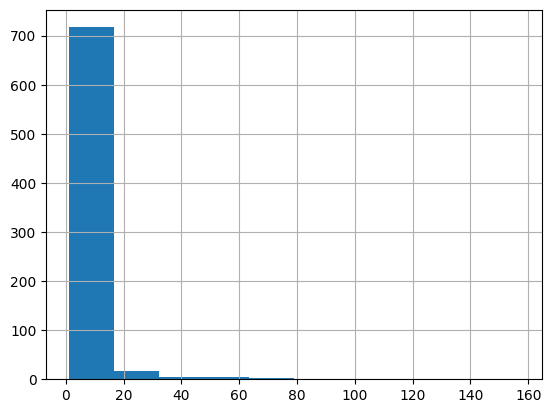

In [108]:
pd.Series(model_value_counts.values).hist()

In [109]:
model_value_counts.value_counts().sort_index(ascending=False).head(20)

count
157    1
101    1
69     1
68     1
61     1
58     1
56     2
47     1
37     1
35     1
33     1
31     2
30     1
26     1
23     2
22     2
21     3
20     1
19     2
18     3
Name: count, dtype: int64

In [110]:
models_lst = model_value_counts.index.tolist()
len(models_lst)

746

In [111]:
", ".join(set(models_lst))

'Cessna 525 Citation CJ1, T207A Turbo Skywagon, A320-232, BOEING 737-86Q, CRJ 200ER, Bonanza F33A, SR22 GTS, DHC-8 103, 737NG 78J/W, A330 303, C-40C, Bombardier CL-600-2B16 Challenger 604, Citation XLS+, CESSNA 560XL Citation Xls, Sinus 912, 737 8AS, A321 211SL, BOEING 737-8Z9, FAN JET FALCON SERIES E Falcon 20e, PA-46 310P Malibu, Citation Sovereign+, 152, Boeing 747 48EFSCD, 747-428, Cessna Citation CJ3, Airbus A320-251N, EMB-135BJ Legacy 600, 390, B737-8MAX 200, CESSNA 172S Skyhawk, BOEING 737-800, Legacy 650, 747 8B5F, Boeing 747-8R7F, PA-46 350P Malibu Mirage, A321-231, ATR 72 600, A330-243, SAAB 340B, 737 548/W, EMB-190 STD, 320-251N(SL), Textron Aviation Citation XLS+,  Boeing 777-3F2(ER), A319-100, 737-86J, REIMS CESSNA F406 Caravan Ii, Dassault Falcon 50, Squirrel AS.350 B3, King Air B200, DC3C (Douglas), LEARJET 45 Learjet, TBM 930, A321-251NX, A220-330, Boeing 737-8K5, PA 46-350P, BOEING 737-8AS, Bombardier Challenger 604, Dassault Falcon 2000LX, ERJ-195AR -&gt;195LR, Boeing

In [112]:
models_lst = model_value_counts.index.tolist()
len(models_lst)

746

Let's delegate to chat gpt one more time. The embedings are stored in `./data/embedings_from_icao.json` file. Let's also store icao to plane model as a json helper. 

In [113]:
icao_to_model_dct = {}
for r in merged_non_na_output.itertuples():
    icao_to_model_dct[r.icao_code] = r.model

with open("./data/icao_to_model.json", "w", encoding="utf-8") as f:
    json.dump(icao_to_model_dct, f, indent=2, ensure_ascii=False)